In [ ]:
# Code snippet 1
# Installing pycaret
!pip install pycaret

In [ ]:
# Code snippet 2
# Importing the dataset
import pandas as pd
data = pd.read_csv('https://raw.githubusercontent.com/nvamsimohan/DallasDSA/refs/heads/main/Zillow%20Tarrant%20County%20Raw%20Data.csv')

data

,beds,baths,sqft,Age,lot_size,property_type,exterior_walls,roof,basement,restaurants,...,beauty_spas,active_life,median_age,married,college_grad,property_tax,insurance,median_school,num_schools,Sales_price
0,1,1,584,9,0,Apartment / Condo / Townhouse,Wood Siding,NaN,0,107,...,47,58,33,65,84,234,81,9.0,3,295850
1,1,1,612,57,0,Apartment / Condo / Townhouse,Brick,Composition Shingle,1,105,...,26,14,39,73,69,169,51,3.0,3,216500
2,1,1,615,59,0,Apartment / Condo / Townhouse,Wood Siding,NaN,0,183,...,74,62,28,15,86,216,74,8.0,3,279900
3,1,1,618,22,33541,Apartment / Condo / Townhouse,Wood Siding,NaN,0,198,...,72,83,36,25,91,265,92,9.0,3,379900
4,1,1,634,30,0,Apartment / Condo / Townhouse,Brick,NaN,0,149,...,50,73,37,20,75,88,30,9.0,3,340000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878,5,6,6381,18,224334,Single-Family,Stucco,Composition Shingle,1,0,...,0,1,46,76,87,1250,381,10.0,3,385000
1879,5,6,6501,66,23086,Single-Family,Brick,Composition Shingle,1,45,...,61,11,42,73,61,1553,473,9.0,3,690000
1880,5,6,7064,27,217800,Single-Family,Metal,Composition Shingle,1,5,...,1,2,43,87,66,942,287,8.0,1,600000
1881,5,6,7500,16,8886,Single-Family,Siding (Alum/Vinyl),Asphalt,1,18,...,8,6,43,61,51,803,245,5.0,2,759900


In [ ]:
# Code snippet 3
# Display data columns
data.columns

Index(['beds', 'baths', 'sqft', 'Age', 'lot_size', 'property_type',
       'exterior_walls', 'roof', 'basement', 'restaurants', 'groceries',
       'nightlife', 'cafes', 'shopping', 'arts_entertainment', 'beauty_spas',
       'active_life', 'median_age', 'married', 'college_grad', 'property_tax',
       'insurance', 'median_school', 'num_schools', 'Sales_price'],
      dtype='object')

<Axes: >

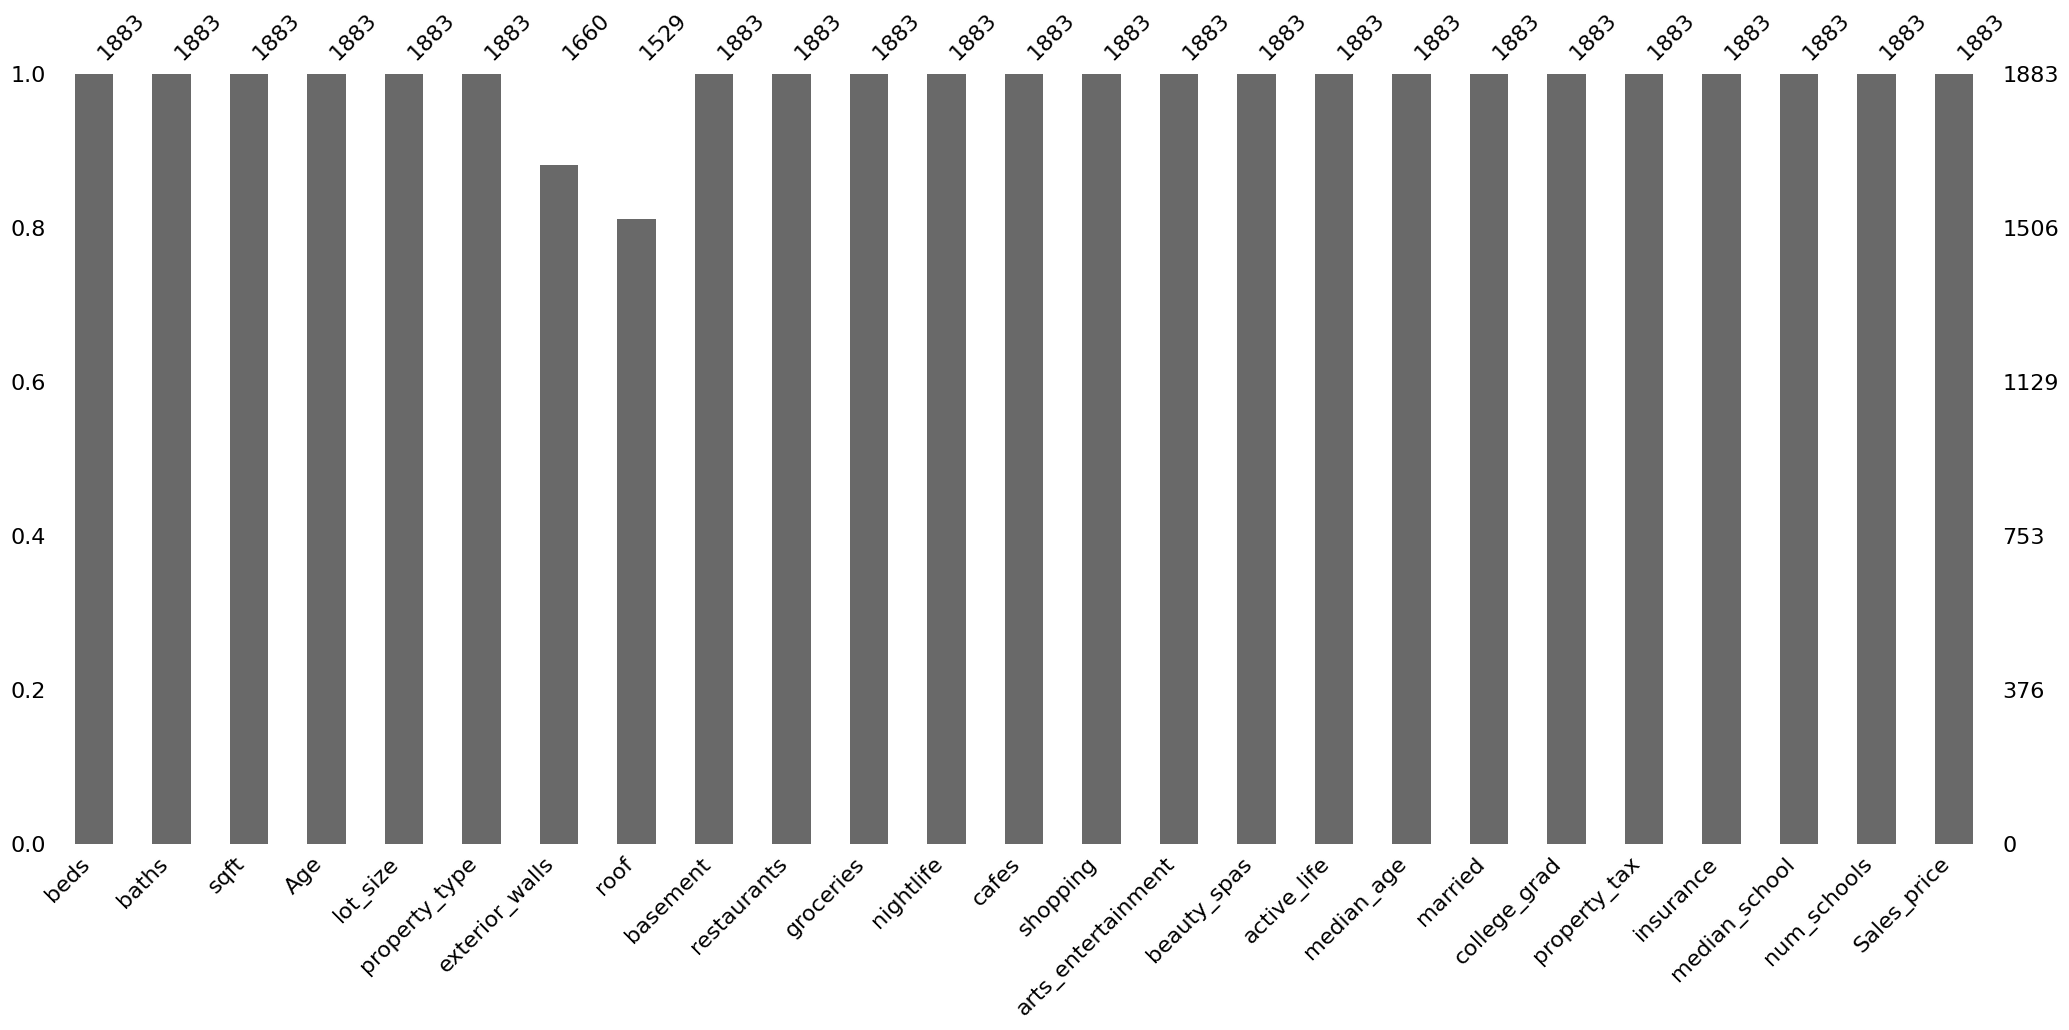

In [ ]:
# Code snippet 3.1
# Displaying missing data
import missingno as msno
msno.bar(data)

In [ ]:
# Code snippet 4
# Importing Anomaly detection modules from pycaret
from pycaret.anomaly import *

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=11, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

In [ ]:
# Code snippet 5
# Setting up the pycaret experiment
anomaly_setup = setup(data)

,Description,Value
0,Session id,8137
1,Original data shape,"(1883, 25)"
2,Transformed data shape,"(1883, 55)"
3,Numeric features,22
4,Categorical features,3
5,Rows with missing values,29.9%
6,Preprocess,True
7,Imputation type,simple
8,Numeric imputation,mean
9,Categorical imputation,mode


In [ ]:
# Code snippet 6
# Building an anomaly detection model using knn algorithm
knn_model = create_model('knn')

Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Code snippet 7
# Identifying the anomalies in the dataset using knn model
knn_anomalies = assign_model(knn_model)

knn_anomalies

,beds,baths,sqft,Age,lot_size,property_type,exterior_walls,roof,basement,restaurants,...,median_age,married,college_grad,property_tax,insurance,median_school,num_schools,Sales_price,Anomaly,Anomaly_Score
0,1,1,584,9,0,Apartment / Condo / Townhouse,Wood Siding,NaN,0,107,...,33,65,84,234,81,9.0,3,295850,0,1084.594394
1,1,1,612,57,0,Apartment / Condo / Townhouse,Brick,Composition Shingle,1,105,...,39,73,69,169,51,3.0,3,216500,0,1576.317227
2,1,1,615,59,0,Apartment / Condo / Townhouse,Wood Siding,NaN,0,183,...,28,15,86,216,74,8.0,3,279900,0,565.527188
3,1,1,618,22,33541,Apartment / Condo / Townhouse,Wood Siding,NaN,0,198,...,36,25,91,265,92,9.0,3,379900,0,12331.592598
4,1,1,634,30,0,Apartment / Condo / Townhouse,Brick,NaN,0,149,...,37,20,75,88,30,9.0,3,340000,0,2073.478478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878,5,6,6381,18,224334,Single-Family,Stucco,Composition Shingle,1,0,...,46,76,87,1250,381,10.0,3,385000,1,113250.929144
1879,5,6,6501,66,23086,Single-Family,Brick,Composition Shingle,1,45,...,42,73,61,1553,473,9.0,3,690000,0,10635.194451
1880,5,6,7064,27,217800,Single-Family,Metal,Composition Shingle,1,5,...,43,87,66,942,287,8.0,1,600000,1,91529.798454
1881,5,6,7500,16,8886,Single-Family,Siding (Alum/Vinyl),Asphalt,1,18,...,43,61,51,803,245,5.0,2,759900,0,7807.313687


In [ ]:
# Code snippet 8
# Displaying only the anomalies from the dataset
knn_anomalies.loc[knn_anomalies['Anomaly'] == 1]

,beds,baths,sqft,Age,lot_size,property_type,exterior_walls,roof,basement,restaurants,...,median_age,married,college_grad,property_tax,insurance,median_school,num_schools,Sales_price,Anomaly,Anomaly_Score
11,1,1,673,17,46609,Apartment / Condo / Townhouse,Concrete Block,NaN,0,193,...,29,15,82,262,90,9.0,3,376750,1,17308.841989
26,1,1,709,17,111513,Apartment / Condo / Townhouse,Wood Siding,NaN,0,213,...,33,40,96,316,109,5.0,3,377000,1,29777.538032
44,1,1,771,17,111513,Apartment / Condo / Townhouse,Wood Siding,NaN,0,213,...,33,40,96,345,119,5.0,3,397400,1,37319.191109
87,1,2,814,14,96703,Apartment / Condo / Townhouse,Wood Siding,Slate,0,75,...,45,60,71,321,93,9.0,3,299700,1,48908.450415
102,2,1,875,72,1220551,Apartment / Condo / Townhouse,Brick,NaN,0,63,...,33,35,87,230,79,6.0,3,292999,1,905798.805148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1875,5,5,7594,16,36154,Single-Family,Brick,Composition Shingle,1,8,...,52,85,57,1061,323,5.5,2,235000,1,19336.134962
1876,5,5,7842,19,436035,Single-Family,Combination,NaN,1,0,...,48,76,62,881,249,7.5,2,760000,1,185009.983326
1877,5,5,8450,18,91911,Single-Family,Other,Composition Shingle,1,7,...,35,91,85,1966,599,10.0,3,555000,1,37590.724787
1878,5,6,6381,18,224334,Single-Family,Stucco,Composition Shingle,1,0,...,46,76,87,1250,381,10.0,3,385000,1,113250.929144


In [ ]:
# Code snippet 9
# Exporting the anomaly data to a csv
knn_anomalies.to_csv('Zillow dataset knn_anomalies.csv')

In [ ]:
# Code snippet 10
# Import clustering modules
from pycaret.clustering import *

In [ ]:
# Code snippet 11
# Setting up clustering experiment
clustering_setup = setup(knn_anomalies, session_id = 123)

,Description,Value
0,Session id,123
1,Original data shape,"(1883, 27)"
2,Transformed data shape,"(1883, 57)"
3,Numeric features,24
4,Categorical features,3
5,Rows with missing values,29.9%
6,Preprocess,True
7,Imputation type,simple
8,Numeric imputation,mean
9,Categorical imputation,mode


In [ ]:
# Code snippet 12
# Building a clustering model using kmeans algo
kmeans_model = create_model('kmeans')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5189,3108.4526,0.6227,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Code snippet 13
# Identifying the clusters using the kmeans algo model
kmeans_clusters = assign_model(kmeans_model)

kmeans_clusters

,beds,baths,sqft,Age,lot_size,property_type,exterior_walls,roof,basement,restaurants,...,married,college_grad,property_tax,insurance,median_school,num_schools,Sales_price,Anomaly,Anomaly_Score,Cluster
0,1,1,584,9,0,Apartment / Condo / Townhouse,Wood Siding,NaN,0,107,...,65,84,234,81,9.0,3,295850,0,1084.594360,Cluster 3
1,1,1,612,57,0,Apartment / Condo / Townhouse,Brick,Composition Shingle,1,105,...,73,69,169,51,3.0,3,216500,0,1576.317261,Cluster 3
2,1,1,615,59,0,Apartment / Condo / Townhouse,Wood Siding,NaN,0,183,...,15,86,216,74,8.0,3,279900,0,565.527161,Cluster 3
3,1,1,618,22,33541,Apartment / Condo / Townhouse,Wood Siding,NaN,0,198,...,25,91,265,92,9.0,3,379900,0,12331.592773,Cluster 1
4,1,1,634,30,0,Apartment / Condo / Townhouse,Brick,NaN,0,149,...,20,75,88,30,9.0,3,340000,0,2073.478516,Cluster 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878,5,6,6381,18,224334,Single-Family,Stucco,Composition Shingle,1,0,...,76,87,1250,381,10.0,3,385000,1,113250.929688,Cluster 1
1879,5,6,6501,66,23086,Single-Family,Brick,Composition Shingle,1,45,...,73,61,1553,473,9.0,3,690000,0,10635.194336,Cluster 2
1880,5,6,7064,27,217800,Single-Family,Metal,Composition Shingle,1,5,...,87,66,942,287,8.0,1,600000,1,91529.796875,Cluster 2
1881,5,6,7500,16,8886,Single-Family,Siding (Alum/Vinyl),Asphalt,1,18,...,61,51,803,245,5.0,2,759900,0,7807.313477,Cluster 2


In [ ]:
# Code snippet 14
# Displaying the number of data points assigned to each of the clusters
kmeans_clusters['Cluster'].value_counts()

,count
Cluster,
Cluster 3,615
Cluster 1,595
Cluster 0,395
Cluster 2,278
